In [64]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [65]:
x=6*np.random.rand(200,1)-3
y=0.8*x**2+0.9*x+2+np.random.randn(200,1)
# y=0.8x**2+0.9x + 2

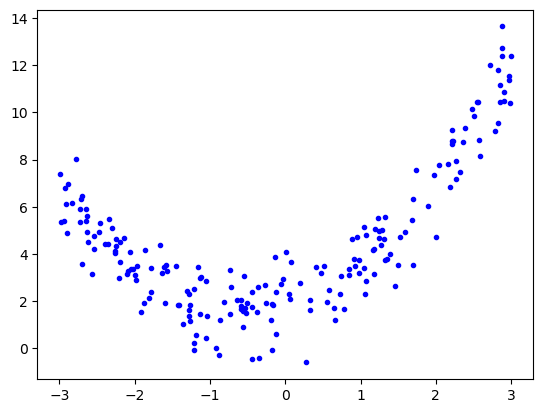

In [66]:
plt.plot(x,y,"b.")


In [67]:
x_train, x_test,y_train , y_test=train_test_split(x,y,test_size=0.2,random_state=23)

In [68]:
lr=  LinearRegression()

In [69]:
lr.fit(x_train,y_train)

LinearRegression()

In [70]:
y_pred= lr.predict(x_test)

In [71]:
r2_score(y_test,y_pred)

0.2077150462877968

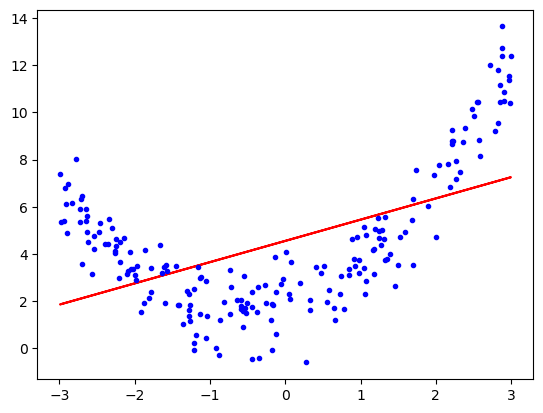

In [72]:
plt.plot(x_train, lr.predict(x_train),color="r")
plt.plot(x,y,"b.")

In [73]:
# applying polynomail linear regression - degree 2
poly = PolynomialFeatures(degree=2)
#It creates a transformer (an object) that can generate polynomial features from your original data.
#degree=2 → it will generate all polynomial terms up to x^2
# ex . , X = [[2], [3], [4]]
""" X_poly =
[[1, 2, 4],   # 1, x, x^2
 [1, 3, 9],
 [1, 4, 16]]
"""

' X_poly =\n[[1, 2, 4],   # 1, x, x^2\n [1, 3, 9],\n [1, 4, 16]]\n'

In [74]:
x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)

In [75]:

print(x_train[0])
print(x_train_trans[0]) # [x^0=1.       x^1=  0.79467235   x^2=0.63150414]


[-1.98021644]
[ 1.         -1.98021644  3.92125714]


In [76]:
# inlcude_bias parameter
#poly = PolynomialFeatures(degree=2,īnclude=False) # it will not give x^0



In [77]:

lr = LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [78]:
y_pred = lr.predict(x_test_trans)


In [79]:
r2_score(y_test,y_pred)


0.8712063230872207

In [80]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.86948431 0.83202964]]
[1.90151084]


In [81]:

x_new=np.linspace(-3, 3, 200).reshape(200, 1)
x_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

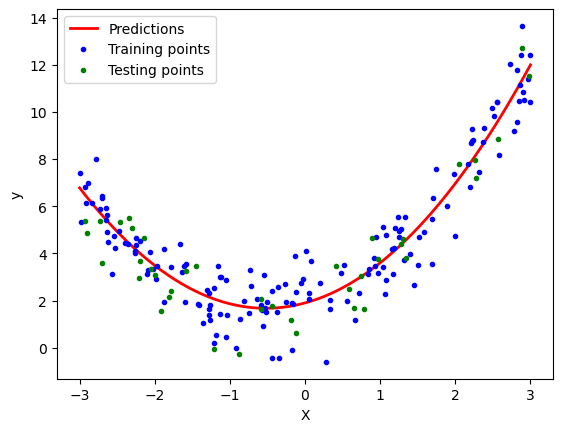

In [82]:
plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [95]:

def polynomial_regression(degree):
    # Generate new x values for smooth curve
    x_new = np.linspace(-3, 3, 200).reshape(200, 1)

    # Build pipeline
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])

    # Fit model
    polynomial_regression.fit(x, y)

    # Predict on x_new (not X_new!)
    y_newbig = polynomial_regression.predict(x_new)

    # Plot
    plt.plot(x_new, y_newbig, 'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()




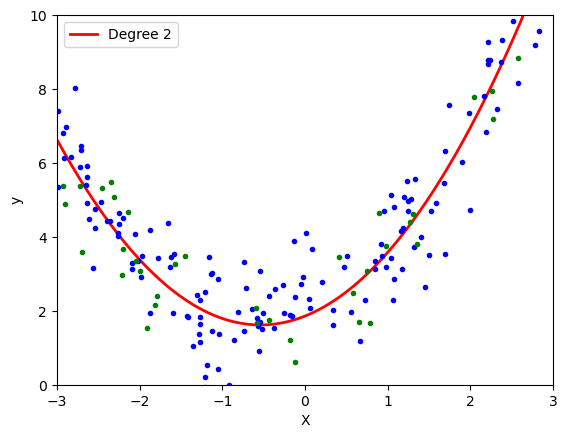

In [101]:
polynomial_regression(2)


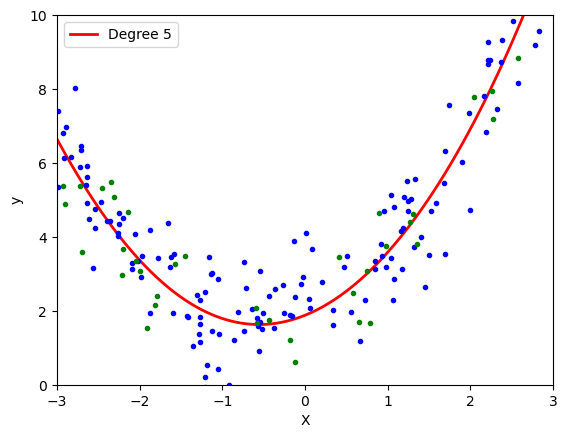

In [99]:
polynomial_regression(5)


C:\Users\sus\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1156: RuntimeWarning: overflow encountered in square
  temp **= 2


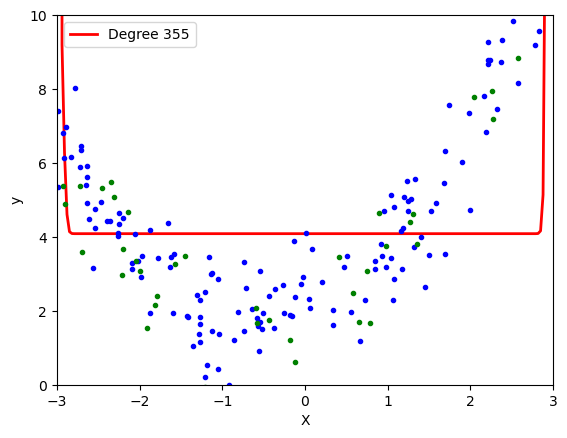

In [100]:
polynomial_regression(355)


In [102]:
#to identify the right no. of degree we can use plots , learning plot , cross-caldidation-r2 score etc.

In [103]:
poly.powers_


array([[0],
       [1],
       [2]], dtype=int64)